In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [3]:
env = gym.make("FrozenLake-v1", is_slippery=False)
n_states = env.observation_space.n
n_actions = env.action_space.n

In [50]:

# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 20000
gamma = 0.99
alpha = 0.1

epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

max_steps_per_episode = 100



In [51]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((n_states, n_actions))
episode_rewards = []


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):
    """
    Selects an action using the epsilon-greedy policy.
    """
    if np.random.rand() < epsilon:
        # Explore: choose a random action
        return env.action_space.sample()
    else:
        # Exploit: choose the action with the highest Q-value
        return np.argmax(Q[state, :])

In [52]:
# -------------------------------------------------
# Generate One Complete Episode
# -------------------------------------------------

def generate_episode(epsilon):
    """
    Generates one episode using the current epsilon-greedy policy.
    Returns a list of (state, action, reward).
    """

    episode = []

    state, info = env.reset()

    for _ in range(max_steps_per_episode):
        action = epsilon_greedy_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)

        episode.append((state, action, reward))

        state = next_state

        if terminated or truncated:
            break

    return episode



In [53]:
# -------------------------------------------------
# Monte Carlo Control
# -------------------------------------------------

epsilon = epsilon_start

for episode_idx in range(num_episodes):
    episode = generate_episode(epsilon)

    # Calculate returns (G) for each state-action pair in the episode
    G = 0
    for t in reversed(range(len(episode))):
        state, action, reward = episode[t]
        G = reward + gamma * G

        # Check if the (state, action) pair is encountered for the first time in the episode
        # (First-visit Monte Carlo)
        first_visit = True
        for prev_t in range(t):
            prev_state, prev_action, _ = episode[prev_t]
            if state == prev_state and action == prev_action:
                first_visit = False
                break

        if first_visit:
            # Update Q-value
            Q[state, action] = Q[state, action] + alpha * (G - Q[state, action])

    # Store total reward for the episode
    total_episode_reward = sum([reward for _, _, reward in episode])
    episode_rewards.append(total_episode_reward)

    # Epsilon decay
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

In [54]:
# -------------------------------------------------
# Extract Greedy Policy
# -------------------------------------------------

optimal_policy = np.argmax(Q, axis=1)
state_values = np.max(Q, axis=1)


In [55]:
# -------------------------------------------------
# Display Results
# -------------------------------------------------

def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)
    print("Name: Hanshika Varthini R")
    print("Register Number:   212223240046   ")
    print("\nLearned Policy:")
    print(policy_grid)


def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(optimal_policy)

success_rate = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", success_rate)




Final Q-table:
[[0.571 0.915 0.563 0.515]
 [0.635 0.    0.555 0.614]
 [0.699 0.692 0.706 0.652]
 [0.713 0.    0.408 0.418]
 [0.699 0.938 0.    0.606]
 [0.    0.    0.    0.   ]
 [0.    0.816 0.    0.776]
 [0.    0.    0.    0.   ]
 [0.723 0.    0.954 0.633]
 [0.856 0.88  0.98  0.   ]
 [0.969 0.99  0.    0.959]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.976 0.99  0.828]
 [0.979 0.989 1.    0.98 ]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.915 0.635 0.706 0.713]
 [0.938 0.    0.816 0.   ]
 [0.954 0.98  0.99  0.   ]
 [0.    0.99  1.    0.   ]]
Name: Hanshika Varthini R
Register Number:   212223240046   

Learned Policy:
[['D' 'L' 'R' 'L']
 ['D' 'L' 'D' 'L']
 ['R' 'R' 'D' 'L']
 ['L' 'R' 'R' 'L']]

Average reward over last 1000 episodes: 0.933


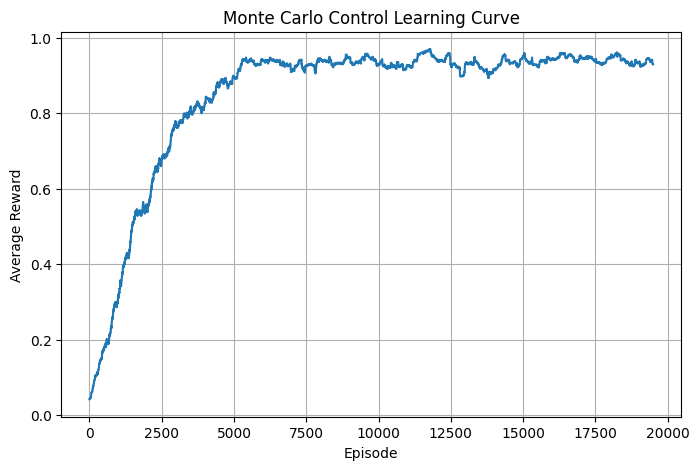

In [56]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500
moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Monte Carlo Control Learning Curve")
plt.grid(True)
plt.show()

env.close()